In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pynamicalsys import PlotStyler
from pynamicalsys import HamiltonianSystem

In [2]:
time_step = 0.01

# Hénon-Heiles

In [3]:
num_ic = 100
dof = 2
q = np.zeros((num_ic, dof))
p = np.zeros((num_ic, dof))
E = 1 / 8  # Total energy of the system
x = 0  # Define the initial condition
y_range = (-0.5, 0.5)
py_range = (-0.5, 0.5)

np.random.seed(13)
for i in range(num_ic):
    while True:
        py = np.random.uniform(*py_range)
        y = np.random.uniform(*y_range)
        px = 2 * (E - x**2 * y + y**3 / 3) - x**2 - y**2 - py**2
        if px > 0:
            q[i] = [x, y]
            p[i] = [np.sqrt(px), py]
            break


num_intersections = 500

In [4]:
ds = HamiltonianSystem(model="henon heiles")

In [5]:
PS = ds.poincare_section(q, p, num_intersections)

In [6]:
PS.shape

(100, 500, 5)

Text(0, 0.5, '$p_y$')

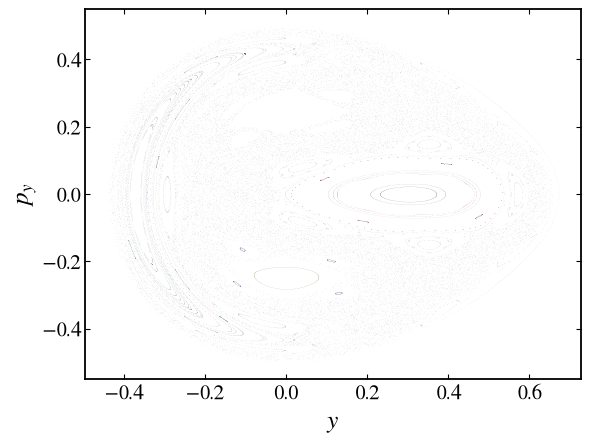

In [7]:
ps = PlotStyler(fontsize=18, markersize=0.1, markeredgewidth=0)
ps.apply_style()
colors = sns.color_palette("hls", num_ic)

for i in range(num_ic):
    plt.plot(PS[i, :, 2], PS[i, :, 4], "o", c=colors[i])
plt.xlabel("$y$")
plt.ylabel("$p_y$")

In [8]:
ds.integrator("imp")

In [9]:
PS = ds.poincare_section(q, p, num_intersections)

Text(0, 0.5, '$p_y$')

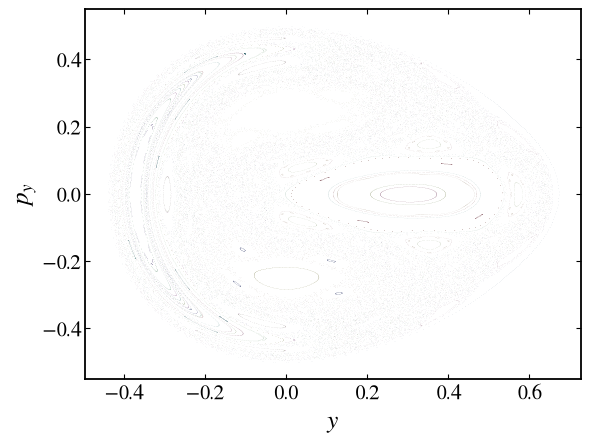

In [10]:
ps = PlotStyler(fontsize=18, markersize=0.1, markeredgewidth=0)
ps.apply_style()
colors = sns.color_palette("hls", num_ic)

for i in range(num_ic):
    plt.plot(PS[i, :, 2], PS[i, :, 4], "o", c=colors[i])
plt.xlabel("$y$")
plt.ylabel("$p_y$")

# Non-separable Hamiltonian

In [ ]:
from numba import njit
from numpy.typing import NDArray
from typing import Union, Sequence

@njit
def two_res_eom(
    q: NDArray[np.float64],
    p: NDArray[np.float64],
    parameters: Union[None, Sequence[float], NDArray[np.float64]] = None,
) -> tuple[NDArray[np.float64], NDArray[np.float64]]:
    """
    Equations of motion for the two-resonance Hamiltonian [1]
        H = J1 + J2 - J1^2 - 3*J1*J2 + J2^2
            + alpha*J1*J2*cos(2*theta1 - 2*theta2)
            + beta*J1*J2^1.5*cos(2*theta1 - 3*theta2).
    Returns (dq/dt, dp/dt) = (dH/dp, -dH/dq).
    parameters[0] = alpha, parameters[1] = beta.

    [1] G. H. Walker and J. Ford, Amplitude Instability and Ergodic Behavior for Conservative Nonlinear Oscillator Systems, Phys. Rev. 188, 416 (1969)
    """
    theta1 = q[0]
    theta2 = q[1]
    J1 = p[0]
    J2 = p[1]

    alpha = parameters[0]
    beta = parameters[1]

    J2_12 = np.sqrt(J2)
    J2_32 = J2 * J2_12

    phase_22 = 2.0 * theta1 - 2.0 * theta2
    phase_23 = 2.0 * theta1 - 3.0 * theta2
    c22 = np.cos(phase_22)
    c23 = np.cos(phase_23)
    s22 = np.sin(phase_22)
    s23 = np.sin(phase_23)

    qdot = np.empty(2)
    pdot = np.empty(2)

    qdot[0] = 1.0 - 2.0 * J1 - 3.0 * J2 + alpha * J2 * c22 + beta * J2_32 * c23
    qdot[1] = (
        1.0 - 3.0 * J1 + 2.0 * J2 + alpha * J1 * c22 + 1.5 * beta * J1 * J2_12 * c23
    )

    pdot[0] = 2.0 * alpha * J1 * J2 * s22 + 2.0 * beta * J1 * J2_32 * s23
    pdot[1] = -2.0 * alpha * J1 * J2 * s22 - 3.0 * beta * J1 * J2_32 * s23

    return qdot, pdot


@njit
def two_res_hess_H(
    q: NDArray[np.float64],
    p: NDArray[np.float64],
    parameters: Union[None, Sequence[float], NDArray[np.float64]] = None,
) -> NDArray[np.float64]:
    """
    Full Hessian of the two-resonance Hamiltonian H(q, p) w.r.t. the
    combined state z = (theta1, theta2, J1, J2), shape (4, 4).
    Not separable: the q-p cross block is nonzero due to the resonance
    coupling terms.
    parameters[0] = alpha, parameters[1] = beta.
    """
    theta1 = q[0]
    theta2 = q[1]
    J1 = p[0]
    J2 = p[1]

    alpha = parameters[0]
    beta = parameters[1]

    J2_12 = np.sqrt(J2)
    J2_32 = J2 * J2_12

    phase_22 = 2.0 * theta1 - 2.0 * theta2
    phase_23 = 2.0 * theta1 - 3.0 * theta2
    c22 = np.cos(phase_22)
    s22 = np.sin(phase_22)
    c23 = np.cos(phase_23)
    s23 = np.sin(phase_23)

    common22 = alpha * J1 * J2
    common23 = beta * J1 * J2_32

    d2H_dtheta1_2 = -4.0 * common22 * c22 - 4.0 * common23 * c23
    d2H_dtheta2_2 = -4.0 * common22 * c22 - 9.0 * common23 * c23
    d2H_dtheta1_dtheta2 = 4.0 * common22 * c22 + 6.0 * common23 * c23

    d2H_dtheta1_dJ1 = -2.0 * alpha * J2 * s22 - 2.0 * beta * J2_32 * s23
    d2H_dtheta2_dJ1 = 2.0 * alpha * J2 * s22 + 3.0 * beta * J2_32 * s23

    d2H_dtheta1_dJ2 = -2.0 * alpha * J1 * s22 - 3.0 * beta * J1 * J2_12 * s23
    d2H_dtheta2_dJ2 = 2.0 * alpha * J1 * s22 + 4.5 * beta * J1 * J2_12 * s23

    d2H_dJ1_2 = -2.0
    d2H_dJ2_2 = 2.0 + beta * J1 * (0.75 / J2_12) * c23
    d2H_dJ1_dJ2 = -3.0 + alpha * c22 + 1.5 * beta * J2_12 * c23

    H = np.zeros((4, 4))

    H[0, 0] = d2H_dtheta1_2
    H[0, 1] = d2H_dtheta1_dtheta2
    H[0, 2] = d2H_dtheta1_dJ1
    H[0, 3] = d2H_dtheta1_dJ2

    H[1, 0] = d2H_dtheta1_dtheta2
    H[1, 1] = d2H_dtheta2_2
    H[1, 2] = d2H_dtheta2_dJ1
    H[1, 3] = d2H_dtheta2_dJ2

    H[2, 0] = d2H_dtheta1_dJ1
    H[2, 1] = d2H_dtheta2_dJ1
    H[2, 2] = d2H_dJ1_2
    H[2, 3] = d2H_dJ1_dJ2

    H[3, 0] = d2H_dtheta1_dJ2
    H[3, 1] = d2H_dtheta2_dJ2
    H[3, 2] = d2H_dJ1_dJ2
    H[3, 3] = d2H_dJ2_2

    return H

def two_res_J1_from_E(
    q: NDArray[np.float64],
    p: NDArray[np.float64],
    E: np.float64,
    parameters: Union[None, Sequence[float], NDArray[np.float64]] = None,
) -> np.float64:
    """
    Solve H(theta1, theta2, J1, J2) = E for J1, given theta1, theta2, J2,
    and the target energy E. Returns the root with the '+' branch of the
    quadratic formula, matching the C implementation.

    H is quadratic in J1:
        -J1^2 + J1*(1 - 3*J2 + alpha*J2*cos(phase_22) + beta*J2^1.5*cos(phase_23))
        + (J2^2 + J2 - E) = 0

    parameters[0] = alpha, parameters[1] = beta.
    """
    theta1 = q[0]
    theta2 = q[1]
    J2 = p[1]

    alpha = parameters[0]
    beta = parameters[1]

    J2_32 = J2 ** 1.5
    phase_22 = 2.0 * theta1 - 2.0 * theta2
    phase_23 = 2.0 * theta1 - 3.0 * theta2

    a = -1.0
    b = (
        1.0
        - 3.0 * J2
        + alpha * J2 * np.cos(phase_22)
        + beta * J2_32 * np.cos(phase_23)
    )
    c = J2 * J2 + J2 - E

    discr = b * b - 4.0 * a * c
    if discr < 0.0:
        return np.float64(np.nan)

    J1 = (-b + np.sqrt(discr)) / (2.0 * a)
    if J1 < 0:
        return np.float64(np.nan)

    return J1

In [4]:
ds = HamiltonianSystem(
    eom=two_res_eom,
    hess_H=two_res_hess_H,
    degrees_of_freedom=2,
    parameters=[0.02, 0.02],
)
parameters = ds.get_parameters()
ds.integrator("imp", tol=1e-9, max_iter=1000)

In [5]:
num_ic = 100
dof = 2
theta = np.zeros((num_ic, dof))  # Angles
J = np.zeros((num_ic, dof))  # Actions
E = 0.2095
theta1 = section_value = 3 * np.pi / 2
theta2_range = (0, 2 * np.pi)
J2_range = (0.005, 0.1)

np.random.seed(1312)
for i in range(num_ic):
    while True:
        J2 = np.random.uniform(*J2_range)
        J[i, 1] = J2
        theta2 = np.random.uniform(*theta2_range)
        theta[i, 0] = theta1
        theta[i, 1] = theta2
        J1 = two_res_J1_from_E(theta[i], J[i], E, parameters)
        if not np.isnan(J1):
            J[i, 0] = J1
            break

num_intersections = 5000

In [6]:
pss = ds.poincare_section(
    theta, J, num_intersections, section_value=3 * np.pi / 2, periodic_section_coordinate=True, crossing=0
)

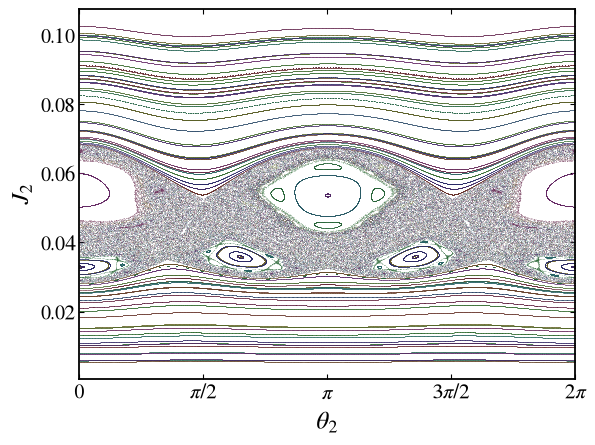

In [8]:
ps = PlotStyler(fontsize=18, markersize=0.25, markeredgewidth=0)
ps.apply_style()
colors = sns.color_palette("hls", num_ic)

for i in range(num_ic):
    plt.plot(pss[i, :, 2] % (2 * np.pi), pss[i, :, 4], "o", c=colors[i])
plt.xlabel(r"$\theta_2$")
plt.ylabel("$J_2$")
plt.xlim(0, 2 * np.pi)
plt.xticks([0, np.pi/2, np.pi, 3 * np.pi /2, 2 * np.pi], 
           ["$0$", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"]);